In [2]:
# Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load FER2013 Dataset
df = pd.read_csv("/content/drive/MyDrive/emotion data/fer2013.csv")
print(df.head())
print("\nDataset Shape :", df.shape)
print("\nEmotion Count\n")
print(df["emotion"].value_counts())

   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training

Dataset Shape : (35887, 3)

Emotion Count

emotion
3    8989
6    6198
4    6077
2    5121
0    4953
5    4002
1     547
Name: count, dtype: int64


In [5]:
# Convert Pixel Strings into Images
pixels = df["pixels"].tolist()
faces = []
for pixel_sequence in pixels:
    face = np.array(pixel_sequence.split(), dtype="float32")
    face = face.reshape(48,48)
    faces.append(face)
X = np.array(faces)
print(X.shape)

(35887, 48, 48)


In [6]:

# Normalize Images
X = X / 255.0
X = X.reshape(-1,48,48,1)
print("Image Shape :", X.shape)

Image Shape : (35887, 48, 48, 1)


In [7]:
# One Hot Encoding Labels

y = tf.keras.utils.to_categorical(df["emotion"],7)
print("Label Shape :", y.shape)

Label Shape : (35887, 7)


In [8]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=df["emotion"])

print("Training Images :", X_train.shape)
print("Testing Images :", X_test.shape)

Training Images : (28709, 48, 48, 1)
Testing Images : (7178, 48, 48, 1)


In [9]:
# Data Augmentation

train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)
train_datagen.fit(X_train)
print("Data Augmentation Ready!")

Data Augmentation Ready!


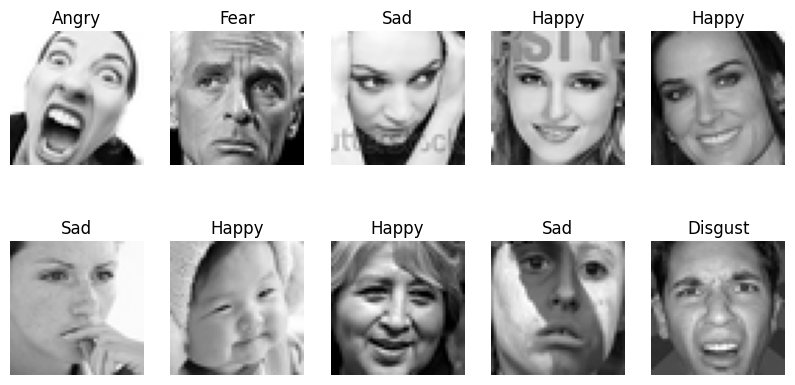

In [10]:
# Show Sample Images
emotion_labels = {

0:"Angry",
1:"Disgust",
2:"Fear",
3:"Happy",
4:"Sad",
5:"Surprise",
6:"Neutral"
}
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(48,48), cmap="gray")
    plt.title(emotion_labels[np.argmax(y_train[i])])
    plt.axis("off")
plt.show()

In [11]:
# Build CNN Model
model = Sequential()
# Input Layer
model.add(Input(shape=(48,48,1)))
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.30))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.50))

# Output Layer
model.add(Dense(7, activation='softmax'))

In [12]:
# Compile Model
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
print("Model Compiled Successfully!")

Model Compiled Successfully!


In [13]:
# Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,653,671 (10.12 MB)

 Trainable params: 2,651,751 (10.12 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [14]:
# Early Stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)
print("CNN Model Ready for Training...")

CNN Model Ready for Training...


In [15]:
# Train Model
history = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=50,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 51s 38ms/step - accuracy: 0.2104 - loss: 2.6044 - val_accuracy: 0.3408 - val_loss: 1.7878
Epoch 2/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.2586 - loss: 2.1586 - val_accuracy: 0.3777 - val_loss: 1.6235
Epoch 3/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.2941 - loss: 1.9719 - val_accuracy: 0.3968 - val_loss: 1.6123
Epoch 4/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.3250 - loss: 1.8322 - val_accuracy: 0.4115 - val_loss: 1.5291
Epoch 5/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.3616 - loss: 1.7277 - val_accuracy: 0.4634 - val_loss: 1.4091
Epoch 6/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.3862 - loss: 1.6383 - val_accuracy: 0.4889 - val_loss: 1.3293
Epoch 7/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.4142 - loss: 1.5506 - val_accuracy: 0.5059 - val_loss: 1.2969
Epoch 8/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.4357 - loss: 1.4923 - 

In [16]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)
pred = model.predict(X_test)
y_pred = np.argmax(pred, axis=1)
y_true = np.argmax(y_test, axis=1)

from sklearn.metrics import classification_report
emotion_names = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Sad",
    "Surprise",
    "Neutral"
]

print(classification_report(y_true, y_pred, target_names=emotion_names))

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6375 - loss: 0.9667
Accuracy: 0.6375035047531128
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
              precision    recall  f1-score   support

       Angry       0.51      0.57      0.54       991
     Disgust       0.49      0.29      0.37       109
        Fear       0.56      0.30      0.39      1024
       Happy       0.84      0.88      0.86      1798
         Sad       0.50      0.55      0.52      1216
    Surprise       0.76      0.78      0.77       800
     Neutral       0.56      0.64      0.60      1240

    accuracy                           0.64      7178
   macro avg       0.60      0.57      0.58      7178
weighted avg       0.63      0.64      0.63      7178



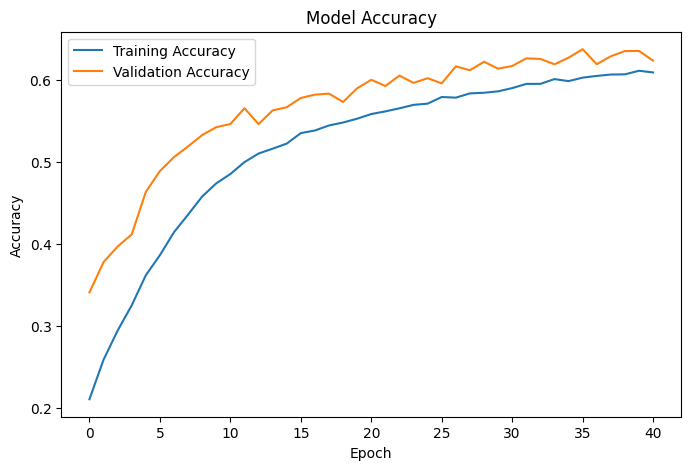

In [17]:
# Accuracy Graph
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

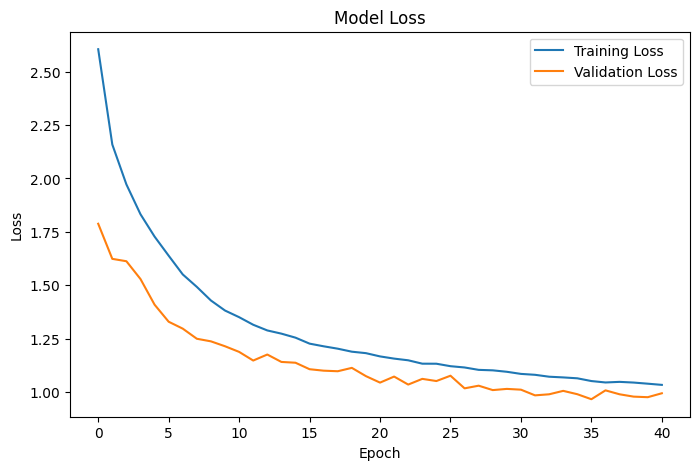

In [18]:
# Loss Graph
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

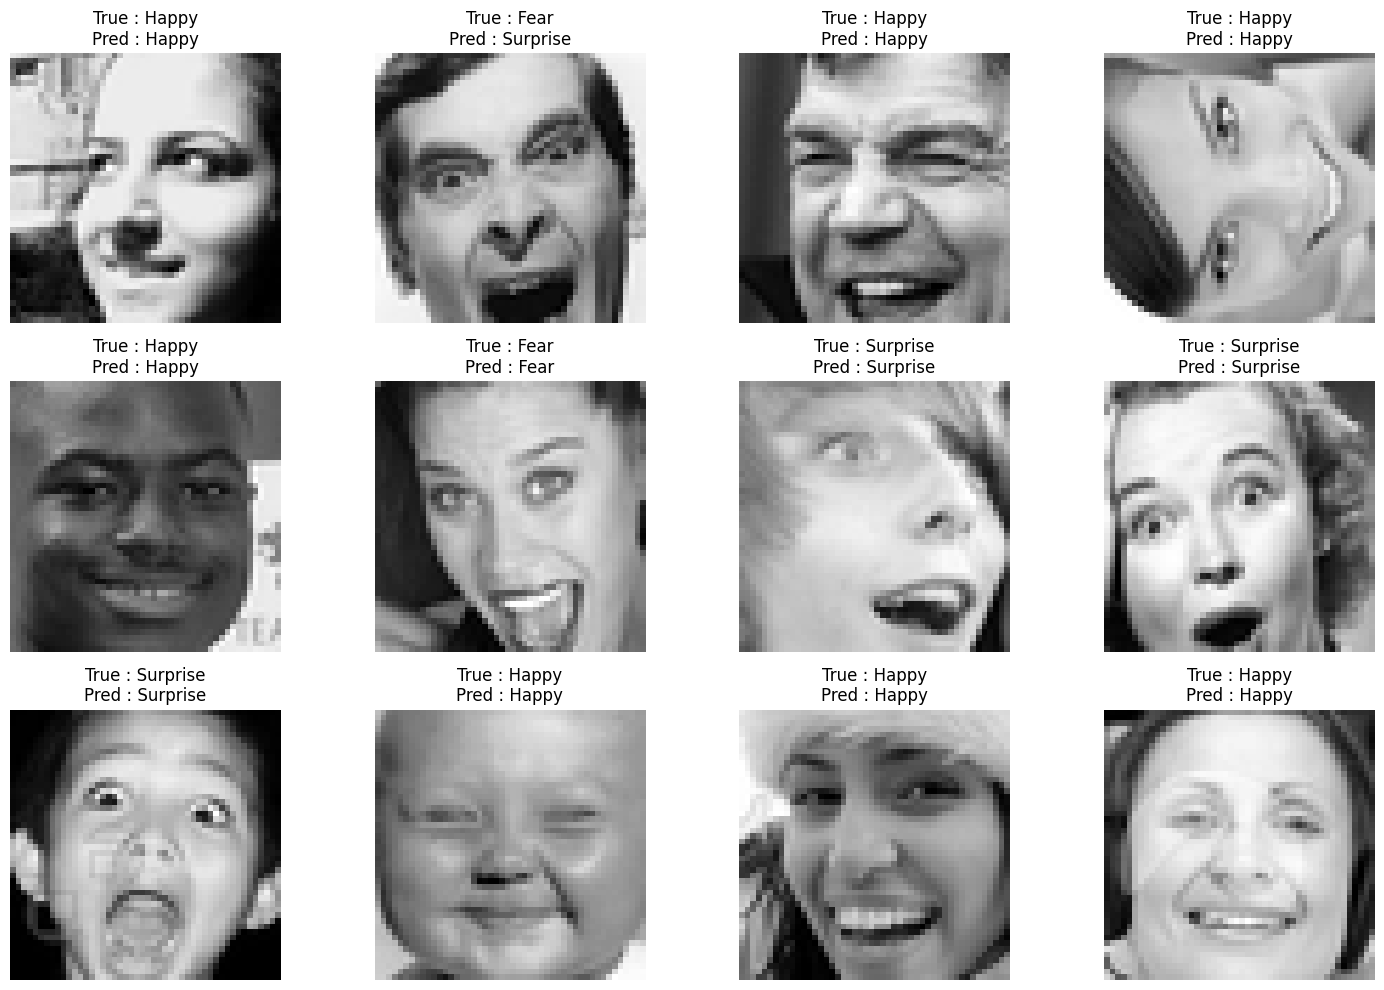

In [19]:
# Show Sample Predictions
plt.figure(figsize=(15,10))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_test[i].reshape(48,48), cmap="gray")
    plt.title(f"True : {emotion_names[y_true[i]]}\nPred : {emotion_names[y_pred[i]]}"    )
    plt.axis("off")
plt.tight_layout()
plt.show()

In [21]:
model.save("/content/drive/MyDrive/emotion data/emotion_model.keras")
print("Model Saved Successfully!")

Model Saved Successfully!
